# Lesson 6: Games of Chance, Betting Markets, and the Kelly Criterion

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, PhD

## Lecture position in the 7-lecture sequence

This lesson uses games of chance to reinforce probability, expected value, simulation, conditional probability, odds, risk management, and optimal bet sizing. The examples are deliberately concrete: coin flips, dice, roulette, poker hands, slot machines, blackjack, sports betting, bookmaker odds, Bayesian updating, and Kelly betting.

By the end of the lesson, students should be able to:

1. Translate between probabilities, odds, and expected values.
2. Explain why casinos and bookmakers can earn positive expected profits even when individual outcomes are risky.
3. Use simulation to approximate probabilities and long-run averages.
4. Distinguish a positive expected value bet from a good bet size.
5. Derive and apply the Kelly Criterion.
6. Explain why overbetting can destroy wealth even when the bettor has a real edge.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Basic probability: coin flips and dice rolls

A probability is a number between 0 and 1 that measures how likely an event is. If an event $A$ can occur in $N_A$ equally likely ways out of $N$ total possible outcomes, then

$$
P(A)=\frac{N_A}{N}.
$$

For a fair coin,

$$
P(\text{Heads})=\frac{1}{2}.
$$

For a fair six-sided die,

$$
P(\text{roll a 6})=\frac{1}{6}.
$$

Simulation lets us approximate these probabilities by repeatedly drawing random outcomes and calculating empirical frequencies.

In [2]:
# Simulate coin flips and dice rolls
n_trials = 10_000
coin_flips = np.random.choice(["Heads", "Tails"], size=n_trials)
dice_rolls = np.random.choice(np.arange(1, 7), size=n_trials)

heads_probability = np.mean(coin_flips == "Heads")
six_probability = np.mean(dice_rolls == 6)

print(f"Empirical probability of Heads: {heads_probability:.4f}")
print(f"Empirical probability of rolling a 6: {six_probability:.4f}")

Empirical probability of Heads: 0.5013
Empirical probability of rolling a 6: 0.1630


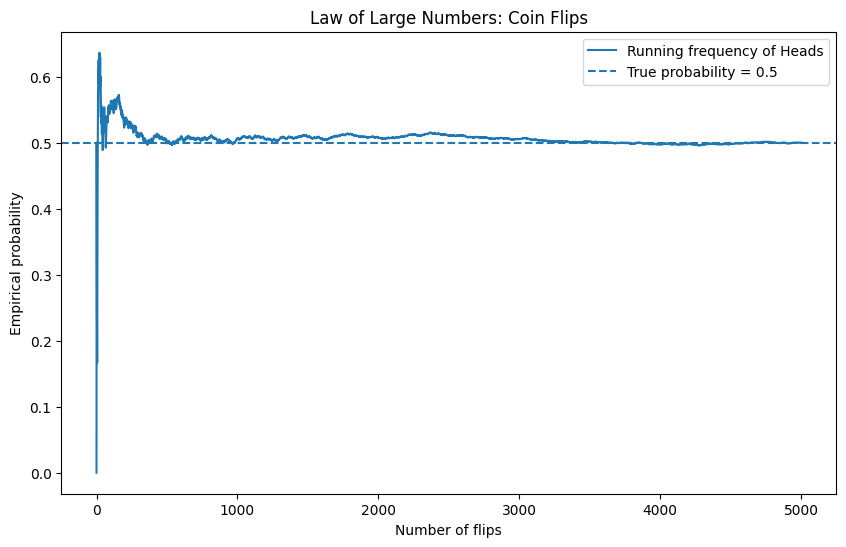

In [3]:
# Law of large numbers for a coin flip
n_flips = 5_000
flips = np.random.choice([1, 0], size=n_flips)  # 1 = heads, 0 = tails
running_heads_frequency = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.plot(running_heads_frequency, label="Running frequency of Heads")
plt.axhline(0.5, linestyle="--", label="True probability = 0.5")
plt.title("Law of Large Numbers: Coin Flips")
plt.xlabel("Number of flips")
plt.ylabel("Empirical probability")
plt.legend()
plt.show()

The **Law of Large Numbers** says that the sample average converges to the expected value as the number of independent draws grows. In this case, the empirical fraction of heads tends toward $0.5$.

## 2. Expected value and casino edge

For a random payoff $X$ with possible outcomes $x_i$ and probabilities $p_i$, expected value is

$$
E[X]=\sum_i p_i x_i.
$$

Expected value is the probability-weighted average payoff. It is not the payoff that must occur on any single play. It is the long-run average payoff if the same gamble is repeated many times under the same conditions.

### Roulette example

In American roulette there are 38 slots: 18 red, 18 black, 0, and 00. A $1$ bet on a single number pays 35-to-1 if it wins and loses the stake otherwise. If $X$ is net profit,

$$
E[X]=\frac{1}{38}(35)+\frac{37}{38}(-1)=-\frac{2}{38}\approx -0.0526.
$$

The player loses about 5.26 cents per dollar wagered in expectation. The casino's expected value is the negative of the player's expected value.

In [4]:
p_win = 1 / 38
p_lose = 1 - p_win
net_win = 35
net_loss = -1
roulette_ev = p_win * net_win + p_lose * net_loss
house_edge = -roulette_ev

print(f"Expected player profit per $1 straight-number bet: ${roulette_ev:.4f}")
print(f"House edge: {house_edge:.2%}")

Expected player profit per $1 straight-number bet: $-0.0526
House edge: 5.26%


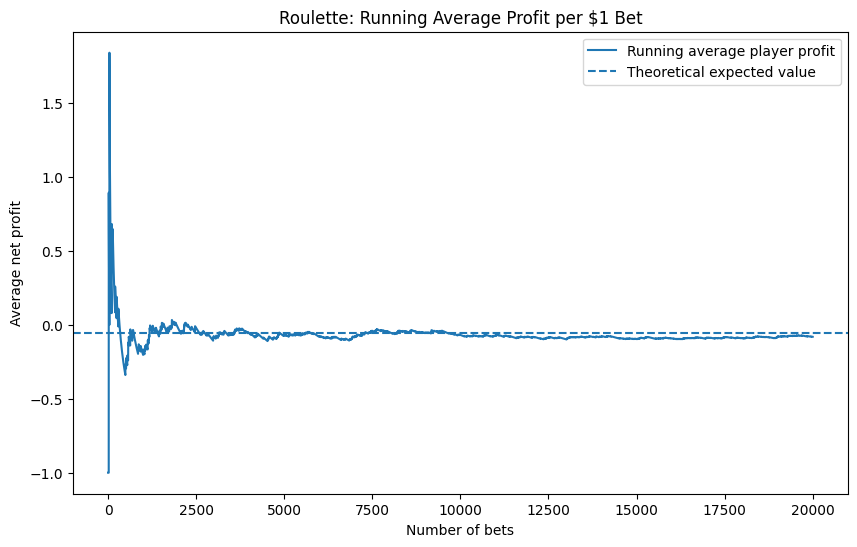

In [5]:
# Simulate repeated roulette bets
n_bets = 20_000
outcomes = np.random.choice([net_win, net_loss], size=n_bets, p=[p_win, p_lose])
running_average_profit = np.cumsum(outcomes) / np.arange(1, n_bets + 1)

plt.plot(running_average_profit, label="Running average player profit")
plt.axhline(roulette_ev, linestyle="--", label="Theoretical expected value")
plt.title("Roulette: Running Average Profit per $1 Bet")
plt.xlabel("Number of bets")
plt.ylabel("Average net profit")
plt.legend()
plt.show()

The path is noisy, but the running average tends to drift toward the theoretical expected value. This is the central reason casinos can earn predictable profits across many plays even though any one spin is uncertain.

## 3. Conditional probability and poker hands

Conditional probability asks how likely an event is given that another event has occurred:

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}.
$$

Poker gives clean examples because many probabilities can be counted combinatorially. The number of possible 5-card hands is

$$
\binom{52}{5}.
$$

A common mistake is to count all hands containing at least one pair when the intended event is **exactly one pair**. The number of exactly-one-pair hands is

$$
\binom{13}{1}\binom{4}{2}\binom{12}{3}4^3.
$$

Explanation:

- Choose the rank of the pair: $\binom{13}{1}$.
- Choose 2 suits from the 4 cards of that rank: $\binom{4}{2}$.
- Choose 3 distinct non-pair ranks from the remaining 12 ranks: $\binom{12}{3}$.
- Choose one suit for each of those 3 side cards: $4^3$.

In [6]:
total_hands = comb(52, 5)
exactly_one_pair_hands = comb(13, 1) * comb(4, 2) * comb(12, 3) * (4 ** 3)
exactly_one_pair_probability = exactly_one_pair_hands / total_hands

print(f"Total 5-card hands: {total_hands:,}")
print(f"Exactly-one-pair hands: {exactly_one_pair_hands:,}")
print(f"Probability of exactly one pair: {exactly_one_pair_probability:.4%}")

Total 5-card hands: 2,598,960
Exactly-one-pair hands: 1,098,240
Probability of exactly one pair: 42.2569%


### Conditional poker example

Suppose your first two cards form a pair. What is the probability that a 5-card hand still ends as exactly one pair?

After receiving a pair, 50 cards remain. To end with exactly one pair, the next 3 cards must all have ranks different from the pair's rank and from one another. There are 12 available ranks and 4 suits per rank, so the favorable completions are

$$
\binom{12}{3}4^3.
$$

The total possible completions are

$$
\binom{50}{3}.
$$

In [7]:
favorable_completions = comb(12, 3) * (4 ** 3)
total_completions = comb(50, 3)
conditional_exact_pair = favorable_completions / total_completions

print(f"P(exactly one pair | first two cards are a pair): {conditional_exact_pair:.4%}")

P(exactly one pair | first two cards are a pair): 71.8367%


## 4. Slot machines and the Law of Large Numbers

Consider a simple slot machine:

- It costs $1$ to play.
- It pays $5$ net of nothing else when a jackpot occurs with probability $1/100$.
- Otherwise the player loses the $1$ cost.

If the net payoff is $X$, then

$$
E[X]=0.01(5-1)+0.99(-1)=0.01(4)-0.99=-0.95.
$$

This is an intentionally unattractive game. The point is that repeated play reveals the expected value more clearly.

Theoretical expected value per play: $-0.95


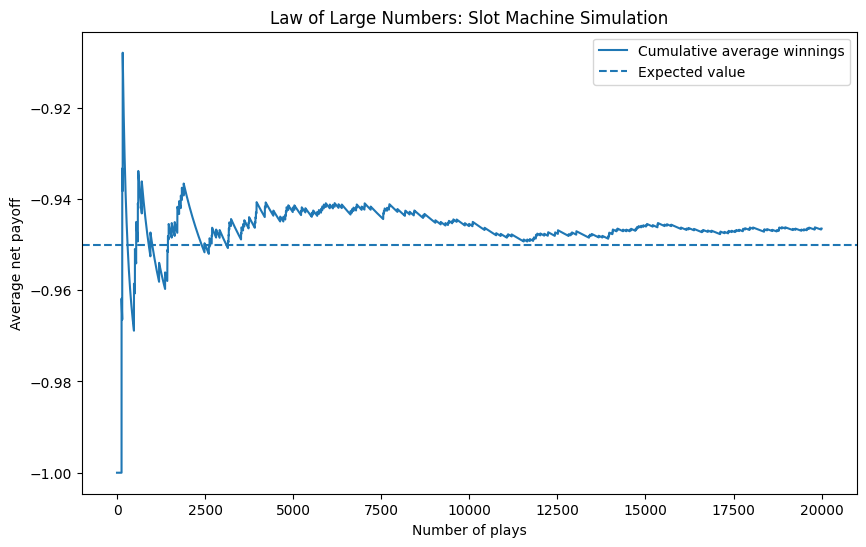

In [8]:
payout = 5
cost = 1
jackpot_probability = 1 / 100
slot_ev = jackpot_probability * (payout - cost) + (1 - jackpot_probability) * (-cost)
print(f"Theoretical expected value per play: ${slot_ev:.2f}")

n_plays = 20_000
slot_results = np.random.choice([payout - cost, -cost], size=n_plays, p=[jackpot_probability, 1 - jackpot_probability])
cumulative_average = np.cumsum(slot_results) / np.arange(1, n_plays + 1)

plt.plot(cumulative_average, label="Cumulative average winnings")
plt.axhline(slot_ev, linestyle="--", label="Expected value")
plt.title("Law of Large Numbers: Slot Machine Simulation")
plt.xlabel("Number of plays")
plt.ylabel("Average net payoff")
plt.legend()
plt.show()

## 5. Monte Carlo simulation and blackjack

Monte Carlo simulation means approximating a probability or expectation by repeated random simulation. Here we build a deliberately simple blackjack model.

The model below is not a full casino blackjack engine. It uses a finite deck, handles aces as either 1 or 11, deals initial two-card hands, and uses a simple rule: both player and dealer hit until reaching at least 17. The goal is pedagogical: show how simulation can estimate outcome probabilities and expected returns when analytic counting is tedious.

In [9]:
def draw_card(deck):
    idx = np.random.randint(len(deck))
    return deck.pop(idx)

def hand_value(cards):
    # Cards are 2-10, J/Q/K as 10, A as 11 initially but can be reduced to 1.
    value = sum(cards)
    aces = cards.count(11)
    while value > 21 and aces > 0:
        value -= 10
        aces -= 1
    return value

def fresh_deck():
    # 4 suits: cards 2-9, four 10-value ranks, and aces as 11.
    single_suit = [2,3,4,5,6,7,8,9,10,10,10,10,11]
    return single_suit * 4

def simulate_blackjack_hand():
    deck = fresh_deck()
    player = [draw_card(deck), draw_card(deck)]
    dealer = [draw_card(deck), draw_card(deck)]
    
    while hand_value(player) < 17:
        player.append(draw_card(deck))
    
    if hand_value(player) > 21:
        return -1
    
    while hand_value(dealer) < 17:
        dealer.append(draw_card(deck))
    
    player_total = hand_value(player)
    dealer_total = hand_value(dealer)
    
    if dealer_total > 21 or player_total > dealer_total:
        return 1
    elif player_total == dealer_total:
        return 0
    else:
        return -1

n_hands = 50_000
blackjack_results = np.array([simulate_blackjack_hand() for _ in range(n_hands)])

win_prob = np.mean(blackjack_results == 1)
loss_prob = np.mean(blackjack_results == -1)
draw_prob = np.mean(blackjack_results == 0)
ev_per_dollar = blackjack_results.mean()

print(f"Win probability:  {win_prob:.2%}")
print(f"Loss probability: {loss_prob:.2%}")
print(f"Push probability: {draw_prob:.2%}")
print(f"Expected net profit per $1 bet under this rule: ${ev_per_dollar:.4f}")

Win probability:  41.02%
Loss probability: 48.59%
Push probability: 10.38%
Expected net profit per $1 bet under this rule: $-0.0757


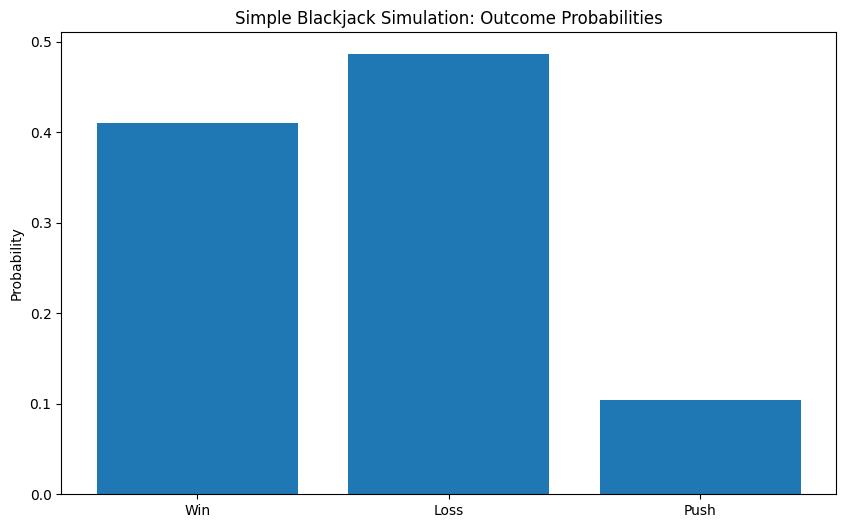

In [10]:
labels = ["Win", "Loss", "Push"]
probabilities = [win_prob, loss_prob, draw_prob]

plt.bar(labels, probabilities)
plt.title("Simple Blackjack Simulation: Outcome Probabilities")
plt.ylabel("Probability")
plt.show()

## 6. Odds, implied probabilities, and betting expected value

Odds are another way of expressing probabilities. If fractional odds are quoted as $b:1$, then a winning $1 bet returns $b$ of net profit plus the original stake. If the bettor's subjective probability of winning is $p$, the expected net profit from betting $1 is

$$
E[X]=p b-(1-p).
$$

The break-even probability is found by setting expected value equal to zero:

$$
p b-(1-p)=0.
$$

Solving gives

$$
p^*=\frac{1}{b+1}.
$$

Thus the implied probability of fractional odds $b:1$ is

$$
\text{Implied probability}=\frac{1}{b+1}.
$$

A bettor has a positive expected value opportunity when their estimated probability is greater than the implied probability.

In [11]:
def fractional_odds_to_implied_probability(b):
    return 1 / (b + 1)

def expected_profit_per_dollar(b, p):
    return p * b - (1 - p)

b = 5      # 5:1 odds
p = 0.15   # bettor believes 15% chance of winning

implied_p = fractional_odds_to_implied_probability(b)
ev = expected_profit_per_dollar(b, p)

print(f"Quoted odds: {b}:1")
print(f"Implied break-even probability: {implied_p:.2%}")
print(f"Bettor subjective probability: {p:.2%}")
print(f"Expected profit per $1 bet: ${ev:.4f}")

Quoted odds: 5:1
Implied break-even probability: 16.67%
Bettor subjective probability: 15.00%
Expected profit per $1 bet: $-0.1000


## 7. Bookmaker margins and the overround

A bookmaker's quoted odds imply probabilities. If the implied probabilities sum to more than 1, the excess is called the **overround** or **vig**. For a set of outcomes with decimal odds $D_i$, the implied probability of outcome $i$ is

$$
\hat p_i=\frac{1}{D_i}.
$$

The overround is

$$
\Omega=\sum_i \hat p_i-1.
$$

A positive overround gives the bookmaker an edge, though the bookmaker still faces risk if bets are unbalanced.

In [12]:
# Three-outcome race with true probabilities
true_probs = np.array([0.30, 0.50, 0.20])
margin = 0.10  # 10% overround

# Inflate implied probabilities so they sum to 1 + margin
implied_probs = true_probs * (1 + margin)
decimal_odds = 1 / implied_probs

overround = implied_probs.sum() - 1

odds_table = pd.DataFrame({
    "Outcome": ["Dog 1", "Dog 2", "Dog 3"],
    "True Probability": true_probs,
    "Implied Probability": implied_probs,
    "Decimal Odds": decimal_odds
})

print(odds_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nOverround: {overround:.2%}")

Outcome  True Probability  Implied Probability  Decimal Odds
  Dog 1            0.3000               0.3300        3.0303
  Dog 2            0.5000               0.5500        1.8182
  Dog 3            0.2000               0.2200        4.5455

Overround: 10.00%


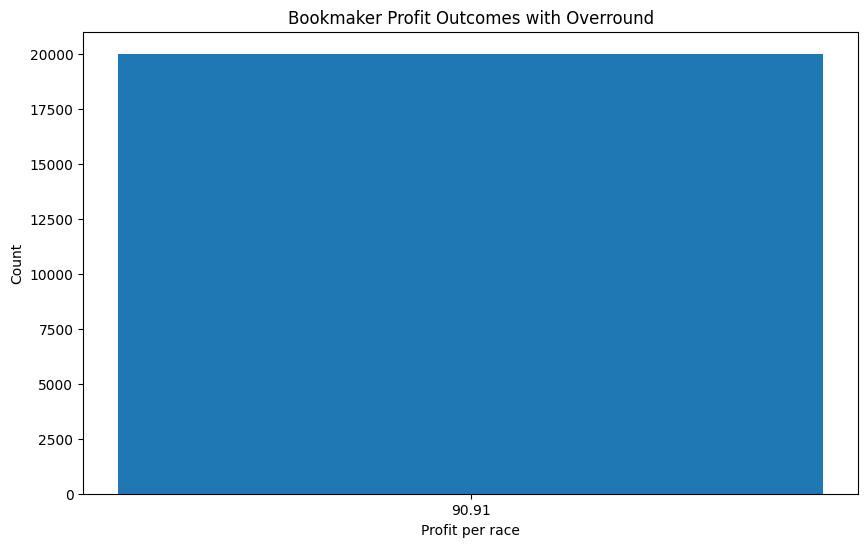

Average bookmaker profit per race: $90.91
Probability bookmaker loses money in a race: 0.00%


In [13]:
# Simulate bookmaker profits when stakes are balanced in proportion to implied probabilities.
n_races = 20_000
stake_pool = 1_000
stakes = stake_pool * implied_probs / implied_probs.sum()
profits = []

for _ in range(n_races):
    winner = np.random.choice(3, p=true_probs)
    payout = stakes[winner] * decimal_odds[winner]
    profits.append(stake_pool - payout)

profits = np.array(profits)
unique_profits, counts = np.unique(np.round(profits, 6), return_counts=True)

plt.bar([str(round(x, 2)) for x in unique_profits], counts)
plt.title("Bookmaker Profit Outcomes with Overround")
plt.xlabel("Profit per race")
plt.ylabel("Count")
plt.show()

print(f"Average bookmaker profit per race: ${profits.mean():.2f}")
print(f"Probability bookmaker loses money in a race: {np.mean(profits < 0):.2%}")

The bookmaker can have a positive average profit and still lose money on individual events. The overround creates positive expected profit; liability management controls the distribution of profits and losses.

## 8. Parlays and multiplying probabilities

A parlay pays only if every leg wins. If the events are independent, the probability of winning a parlay is the product of the individual probabilities:

$$
P(A_1\cap A_2\cap\cdots\cap A_n)=\prod_{i=1}^n P(A_i).
$$

Parlays can produce large quoted payouts because multiplying probabilities quickly produces a small total probability.

In [14]:
match_probabilities = np.array([0.60, 0.70, 0.50])
parlay_probability = np.prod(match_probabilities)
fair_decimal_odds = 1 / parlay_probability
bet = 10
fair_total_return = bet * fair_decimal_odds
fair_net_profit = fair_total_return - bet

print(f"Individual win probabilities: {match_probabilities}")
print(f"Parlay win probability: {parlay_probability:.2%}")
print(f"Fair decimal odds: {fair_decimal_odds:.2f}")
print(f"Fair net profit on a $10 parlay: ${fair_net_profit:.2f}")

n_simulations = 50_000
outcomes = np.random.rand(n_simulations, len(match_probabilities)) < match_probabilities
parlay_wins = np.all(outcomes, axis=1)
print(f"Simulated parlay win probability: {parlay_wins.mean():.2%}")

Individual win probabilities: [0.6 0.7 0.5]
Parlay win probability: 21.00%
Fair decimal odds: 4.76
Fair net profit on a $10 parlay: $37.62
Simulated parlay win probability: 20.90%


## 9. Bayesian updating: changing probabilities as information arrives

Bayesian updating combines a prior probability with new evidence. Bayes' rule is

$$
P(H\mid E)=\frac{P(E\mid H)P(H)}{P(E)}.
$$

For two exhaustive hypotheses $A$ and $B$,

$$
P(E)=P(E\mid A)P(A)+P(E\mid B)P(B).
$$

In betting language, a prior probability might be a pre-fight probability, and the evidence might be information from weigh-ins, injuries, recent performance, or tactical matchups.

In [15]:
# Boxing example: update probability of Fighter A winning after favorable evidence.
p_A_prior = 0.60
p_B_prior = 1 - p_A_prior
p_E_given_A = 0.70
p_E_given_B = 0.50

p_E = p_E_given_A * p_A_prior + p_E_given_B * p_B_prior
p_A_posterior = p_E_given_A * p_A_prior / p_E
p_B_posterior = p_E_given_B * p_B_prior / p_E

print(f"Prior P(A wins):      {p_A_prior:.2%}")
print(f"Posterior P(A wins):  {p_A_posterior:.2%}")
print(f"Posterior P(B wins):  {p_B_posterior:.2%}")

Prior P(A wins):      60.00%
Posterior P(A wins):  67.74%
Posterior P(B wins):  32.26%


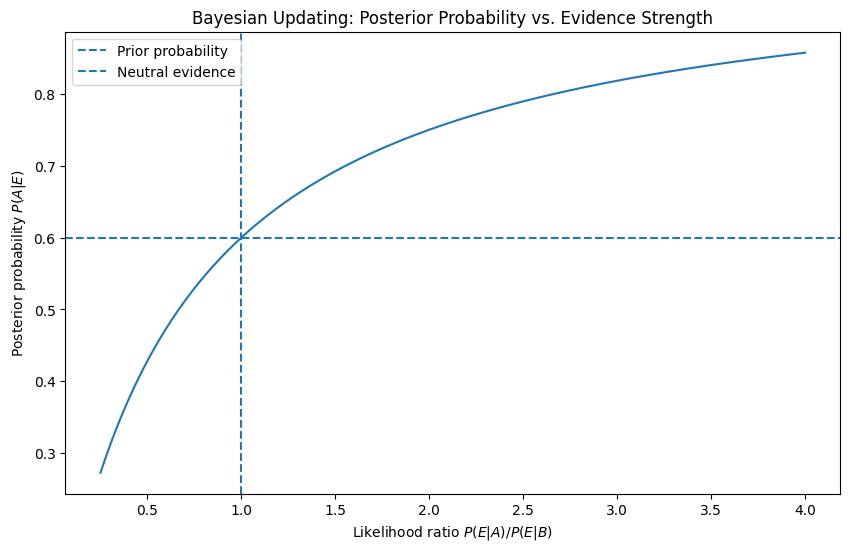

In [16]:
# Visualize Bayesian updating as evidence becomes more favorable to A.
likelihood_ratios = np.linspace(0.25, 4.0, 200)  # P(E|A)/P(E|B)
posterior_probs = []
for lr in likelihood_ratios:
    p_E_A = lr * 0.5
    p_E_B = 0.5
    p_E_total = p_E_A * p_A_prior + p_E_B * p_B_prior
    posterior_probs.append(p_E_A * p_A_prior / p_E_total)

plt.plot(likelihood_ratios, posterior_probs)
plt.axhline(p_A_prior, linestyle="--", label="Prior probability")
plt.axvline(1, linestyle="--", label="Neutral evidence")
plt.title("Bayesian Updating: Posterior Probability vs. Evidence Strength")
plt.xlabel(r"Likelihood ratio $P(E|A)/P(E|B)$")
plt.ylabel(r"Posterior probability $P(A|E)$")
plt.legend()
plt.show()

## 10. The Kelly Criterion

Expected value tells us whether a bet is favorable. It does **not** tell us how much to bet. The Kelly Criterion chooses the bet fraction that maximizes expected log wealth.

Suppose a bettor has wealth $W$, bets fraction $f$ of wealth, wins with probability $p$, loses with probability $q=1-p$, and receives net odds $b:1$ when the bet wins. Wealth next period is

$$
W_{t+1}=\begin{cases}
W_t(1+fb), & \text{with probability } p,\\
W_t(1-f), & \text{with probability } q.
\end{cases}
$$

The expected log growth rate is

$$
g(f)=p\log(1+fb)+q\log(1-f).
$$

Differentiate with respect to $f$:

$$
\frac{dg}{df}=\frac{pb}{1+fb}-\frac{q}{1-f}.
$$

Set this equal to zero and solve:

$$
\frac{pb}{1+fb}=\frac{q}{1-f}.
$$

This gives the Kelly fraction

$$
f^*=\frac{bp-q}{b}=\frac{p(b+1)-1}{b}.
$$

If $f^*<0$, the bettor should not take the long side of the bet.

In [17]:
def kelly_fraction(b, p):
    q = 1 - p
    return (b * p - q) / b

def expected_log_growth(f, b, p):
    q = 1 - p
    if np.any(1 + f*b <= 0) or np.any(1 - f <= 0):
        return np.nan
    return p * np.log(1 + f*b) + q * np.log(1 - f)

examples = pd.DataFrame({
    "Game": ["Fair even-money coin", "Unfavorable roulette red/black", "Favorable sports bet"],
    "Net odds b": [1.0, 1.0, 2.0],
    "Win probability p": [0.50, 18/38, 0.60]
})
examples["Kelly fraction"] = [kelly_fraction(b, p) for b, p in zip(examples["Net odds b"], examples["Win probability p"])]
examples["EV per $1"] = [expected_profit_per_dollar(b, p) for b, p in zip(examples["Net odds b"], examples["Win probability p"])]
print(examples.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                          Game  Net odds b  Win probability p  Kelly fraction  EV per $1
          Fair even-money coin      1.0000             0.5000          0.0000     0.0000
Unfavorable roulette red/black      1.0000             0.4737         -0.0526    -0.0526
          Favorable sports bet      2.0000             0.6000          0.4000     0.8000


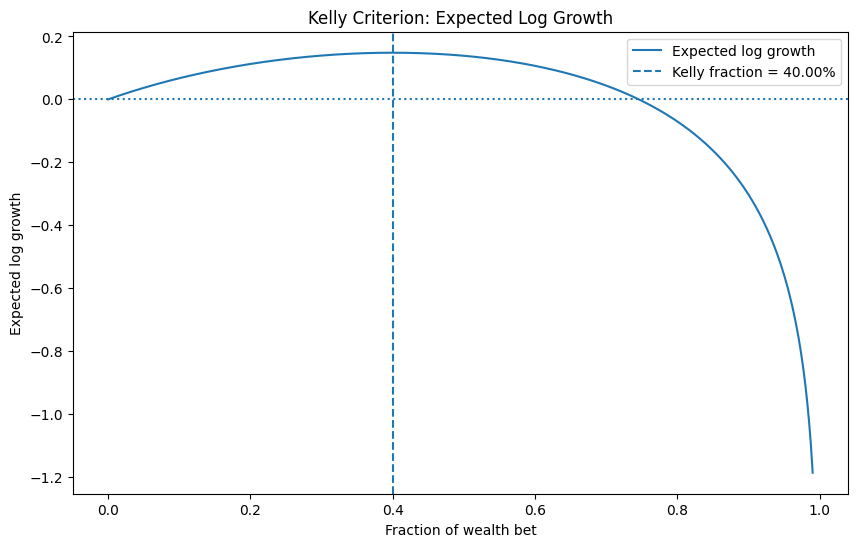

In [18]:
# Expected log growth as a function of bet fraction
b = 2.0
p = 0.60
f_star = kelly_fraction(b, p)
f_grid = np.linspace(0.0, 0.99, 400)
g_grid = np.array([expected_log_growth(f, b, p) for f in f_grid])

plt.plot(f_grid, g_grid, label="Expected log growth")
plt.axvline(f_star, linestyle="--", label=f"Kelly fraction = {f_star:.2%}")
plt.axhline(0, linestyle=":")
plt.title("Kelly Criterion: Expected Log Growth")
plt.xlabel("Fraction of wealth bet")
plt.ylabel("Expected log growth")
plt.legend()
plt.show()

A key lesson is that betting too much can reduce expected log growth even when the bet has positive expected value. This is why bankroll management is not an afterthought; it is part of the optimization problem.

## 11. Kelly betting, fractional Kelly, and drawdown risk

Kelly betting maximizes long-run expected log growth under the assumed probabilities and odds. But full Kelly can produce large drawdowns. Many practitioners use **fractional Kelly**, such as half-Kelly, to reduce volatility and model-error risk.

The following simulation compares half-Kelly, full-Kelly, and overbetting at 150% of Kelly.

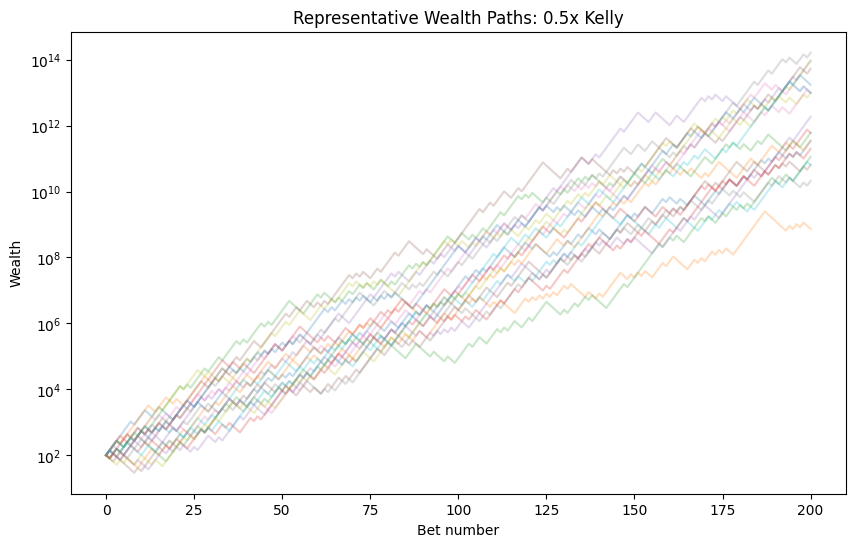

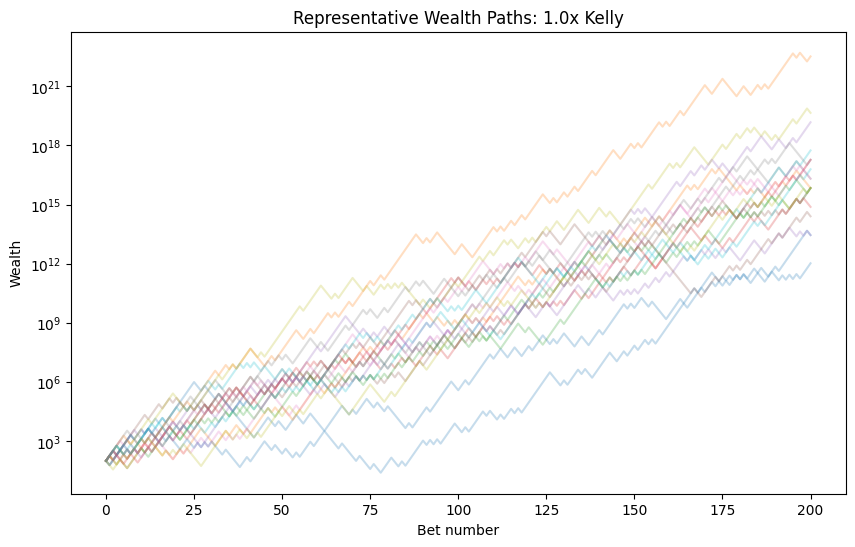

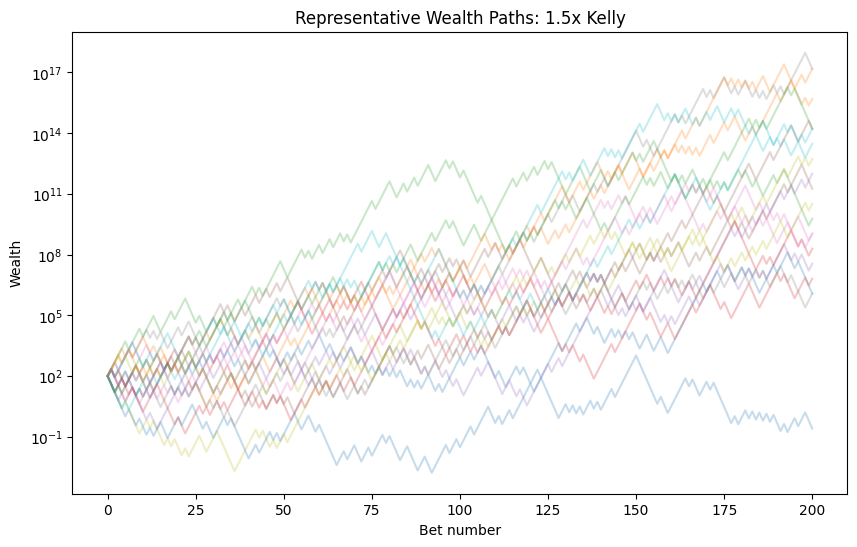

In [19]:
def simulate_wealth_paths(initial_wealth, b, p, f_multiplier, n_bets, n_paths):
    f = f_multiplier * kelly_fraction(b, p)
    paths = np.zeros((n_paths, n_bets + 1))
    paths[:, 0] = initial_wealth
    for t in range(1, n_bets + 1):
        wins = np.random.rand(n_paths) < p
        paths[:, t] = np.where(
            wins,
            paths[:, t-1] * (1 + f*b),
            paths[:, t-1] * (1 - f)
        )
    return paths

initial_wealth = 100
n_bets = 200
n_paths = 1_000
b = 2.0
p = 0.60
multipliers = [0.5, 1.0, 1.5]
paths_by_strategy = {m: simulate_wealth_paths(initial_wealth, b, p, m, n_bets, n_paths) for m in multipliers}

# Plot representative paths
for m, paths in paths_by_strategy.items():
    plt.plot(paths[:20].T, alpha=0.25)
    plt.title(f"Representative Wealth Paths: {m}x Kelly")
    plt.xlabel("Bet number")
    plt.ylabel("Wealth")
    plt.yscale("log")
    plt.show()

  Strategy  Median final wealth             Mean final wealth  5th percentile final wealth  Median max drawdown  P(final wealth < initial)
0.5x Kelly    606126456535.2372          368570404985756.3125               734694276.4017               0.7369                     0.0000
1.0x Kelly 767009323453495.7500  23049273698158938947584.0000              1443263360.2855               0.9673                     0.0000
1.5x Kelly    180103024019.6153 914410632184466572836864.0000                     235.0546               0.9996                     0.0430


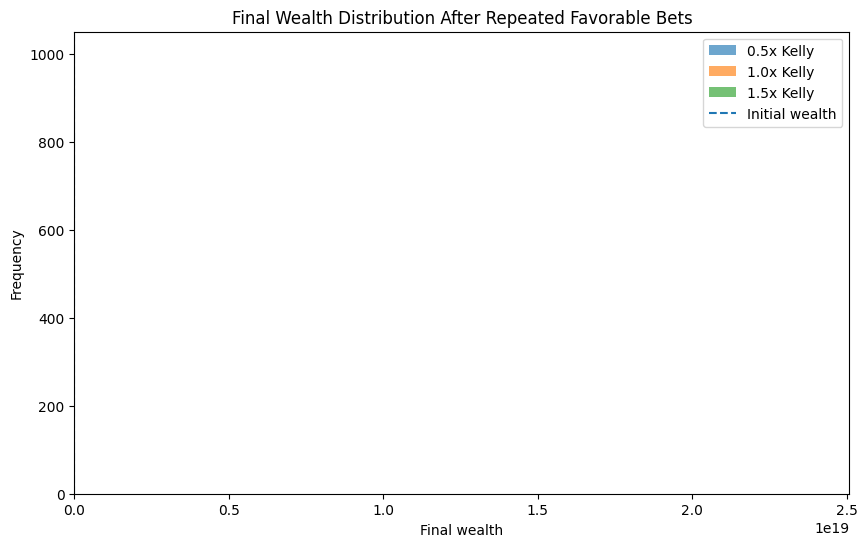

In [20]:
# Distribution of final wealth by strategy
summary_rows = []
for m, paths in paths_by_strategy.items():
    final = paths[:, -1]
    max_so_far = np.maximum.accumulate(paths, axis=1)
    drawdowns = 1 - paths / max_so_far
    max_drawdown = drawdowns.max(axis=1)
    summary_rows.append({
        "Strategy": f"{m}x Kelly",
        "Median final wealth": np.median(final),
        "Mean final wealth": np.mean(final),
        "5th percentile final wealth": np.percentile(final, 5),
        "Median max drawdown": np.median(max_drawdown),
        "P(final wealth < initial)": np.mean(final < initial_wealth)
    })

kelly_summary = pd.DataFrame(summary_rows)
print(kelly_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

plt.hist([paths_by_strategy[m][:, -1] for m in multipliers], bins=60, label=[f"{m}x Kelly" for m in multipliers], alpha=0.65)
plt.axvline(initial_wealth, linestyle="--", label="Initial wealth")
plt.title("Final Wealth Distribution After Repeated Favorable Bets")
plt.xlabel("Final wealth")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0, np.percentile(paths_by_strategy[1.5][:, -1], 95))
plt.show()

## 12. Bettor versus bookmaker risk management

A bettor asks: **Do I have positive expected value, and what fraction of bankroll should I risk?**

A bookmaker asks: **How do I set odds so that implied probabilities include a margin, and how do I manage liabilities across possible outcomes?**

If too much money arrives on one side of a market, the bookmaker may change odds to attract bets on the other side or reduce exposure. The bookmaker's problem is not only expected profit; it is also balance-sheet risk.

Stake pool: $100,000
Bookmaker profit if A wins: $-8,000
Bookmaker profit if B wins: $12,000


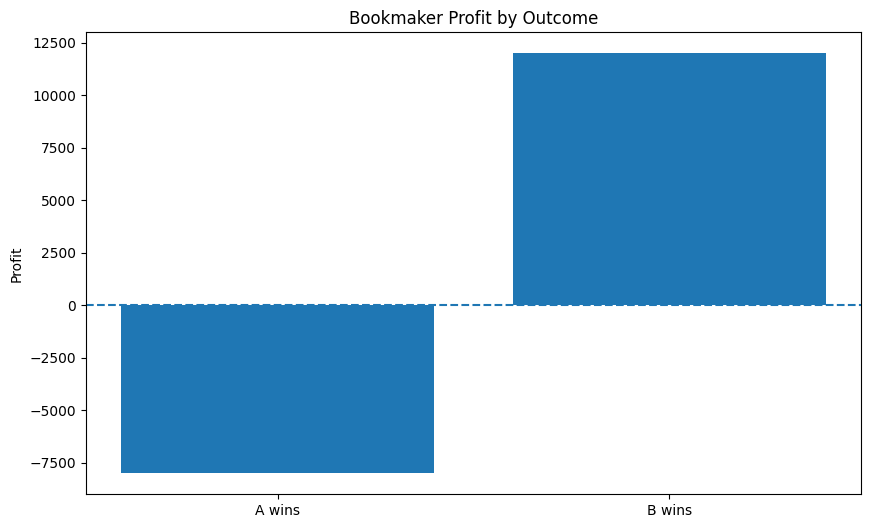

In [21]:
# Bookmaker liability example
stake_A = 60_000
stake_B = 40_000
decimal_odds_A = 1.80
decimal_odds_B = 2.20
stake_pool = stake_A + stake_B

liability_A = stake_A * decimal_odds_A
liability_B = stake_B * decimal_odds_B
profit_if_A_wins = stake_pool - liability_A
profit_if_B_wins = stake_pool - liability_B

print(f"Stake pool: ${stake_pool:,.0f}")
print(f"Bookmaker profit if A wins: ${profit_if_A_wins:,.0f}")
print(f"Bookmaker profit if B wins: ${profit_if_B_wins:,.0f}")

plt.bar(["A wins", "B wins"], [profit_if_A_wins, profit_if_B_wins])
plt.axhline(0, linestyle="--")
plt.title("Bookmaker Profit by Outcome")
plt.ylabel("Profit")
plt.show()

## 13. Summary

This lecture used games of chance to connect probability theory to economic and financial decision-making.

Key takeaways:

1. **Expected value** is a probability-weighted average payoff.
2. **Simulation** approximates probabilities and expected values when direct calculation is difficult.
3. **The Law of Large Numbers** explains why casino and bookmaker edges become powerful over many repetitions.
4. **Odds** are prices of probabilistic claims.
5. **Overround** is the bookmaker's built-in margin.
6. **Bayesian updating** explains how probabilities should change when new information arrives.
7. **Kelly betting** separates the question of whether a bet is favorable from the question of how large the bet should be.
8. **Overbetting** can be disastrous even when the bettor has a positive edge.

The next lecture can use these ideas to transition into risk, insurance, prediction markets, auctions, mechanism design, or applied econometric modeling.